# ambitionBox analysis

In [140]:
import pandas as pd
import matplotlib.pyplot as plt

import numpy as np
import seaborn as sns

In [141]:
print("hello")

hello


# 1. Data Loading

In [142]:
df=pd.read_csv("companies.csv")
df

,name,rating,reviews,industry,location
0,TCS,3.3,(1.2L),IT Services & Consulting,Bengaluru +445 other locations
1,Accenture,3.7,(74k),IT Services & Consulting,Bengaluru +259 other locations
2,Wipro,3.6,(65.5k),IT Services & Consulting,Hyderabad +374 other locations
3,Cognizant,3.7,(61.9k),IT Services & Consulting,Hyderabad +233 other locations
4,Capgemini,3.6,(53.8k),IT Services & Consulting,Bengaluru +183 other locations
...,...,...,...,...,...
1575,ChannelPlay,3.8,(691),Marketing & Advertising,Gurugram +95 other locations
1576,Bisk Farm,4.0,(691),Food Processing,Kolkata +140 other locations
1577,SG Analytics,2.5,(691),Analytics & KPO,Pune +12 other locations
1578,Autoliv,3.9,(690),Auto Components,Bengaluru +23 other locations


In [143]:
df.head() # data show

,name,rating,reviews,industry,location
0,TCS,3.3,(1.2L),IT Services & Consulting,Bengaluru +445 other locations
1,Accenture,3.7,(74k),IT Services & Consulting,Bengaluru +259 other locations
2,Wipro,3.6,(65.5k),IT Services & Consulting,Hyderabad +374 other locations
3,Cognizant,3.7,(61.9k),IT Services & Consulting,Hyderabad +233 other locations
4,Capgemini,3.6,(53.8k),IT Services & Consulting,Bengaluru +183 other locations


In [144]:
df.tail()

,name,rating,reviews,industry,location
1575,ChannelPlay,3.8,(691),Marketing & Advertising,Gurugram +95 other locations
1576,Bisk Farm,4.0,(691),Food Processing,Kolkata +140 other locations
1577,SG Analytics,2.5,(691),Analytics & KPO,Pune +12 other locations
1578,Autoliv,3.9,(690),Auto Components,Bengaluru +23 other locations
1579,Blue Yonder,3.6,(690),Software Product,Bengaluru +14 other locations


In [145]:
df.columns

Index(['name', 'rating', 'reviews', 'industry', 'location'], dtype='object')

In [146]:
df.shape

(1580, 5)

# 2. Data Understanding (EDA Start)

In [147]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1580 entries, 0 to 1579
Data columns (total 5 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   name      1580 non-null   object 
 1   rating    1580 non-null   float64
 2   reviews   1580 non-null   object 
 3   industry  1580 non-null   object 
 4   location  1577 non-null   object 
dtypes: float64(1), object(4)
memory usage: 61.8+ KB


In [148]:
df.describe()

,rating
count,1580.000000
mean,3.779937
std,0.355090
min,1.300000
25%,3.600000
50%,3.800000
75%,4.000000
max,4.900000


In [149]:
# data type
df.dtypes

name         object
rating      float64
reviews      object
industry     object
location     object
dtype: object

In [150]:
df.nunique()

name        1575
rating        29
reviews      373
industry      78
location    1120
dtype: int64

# 3. Missing Values Analysis

In [151]:
df.isnull().sum()

name        0
rating      0
reviews     0
industry    0
location    3
dtype: int64

In [152]:
df[df.isnull().any(axis=1)]
# df[df['location'].isnull()]

,name,rating,reviews,industry,location
247,IndusInd Nippon Life Insurance,3.4,(3.4k),Mumbai +494 other locations,NaN
651,Labmentix,4.5,(1.6k),Bengaluru +32 other locations,NaN
1325,Bill Gosling Outsourcing India,3.5,(810),Gurugram +13 other locations,NaN


In [153]:
df['location'] = df['location'].fillna('Unknown')

In [ ]:
# (3.4k) remove () and convert 3.4k
df['reviews'] = df['reviews'].str.replace(r'[()]', '', regex=True)


In [155]:
df.dtypes

name         object
rating      float64
reviews      object
industry     object
location     object
dtype: object

In [156]:
df.head()

,name,rating,reviews,industry,location
0,TCS,3.3,1.2L,IT Services & Consulting,Bengaluru +445 other locations
1,Accenture,3.7,74k,IT Services & Consulting,Bengaluru +259 other locations
2,Wipro,3.6,65.5k,IT Services & Consulting,Hyderabad +374 other locations
3,Cognizant,3.7,61.9k,IT Services & Consulting,Hyderabad +233 other locations
4,Capgemini,3.6,53.8k,IT Services & Consulting,Bengaluru +183 other locations


In [157]:
# convert 1.2 L into 120000
def convert_reviews(x):
    x = x.strip('()')
    if 'L' in x:
        return float(x.replace('L', '')) * 100000
    elif 'k' in x:
        return float(x.replace('k', '')) * 1000
    else:
        return int(x)

df['reviews'] = df['reviews'].apply(convert_reviews)



In [158]:
# convert data type
df['reviews']=df['reviews'].astype('int64')

# 4. Duplicate Analysis

In [159]:
df.duplicated().sum()

np.int64(5)

In [160]:
# show duplicate
df[df.duplicated()]

,name,rating,reviews,industry,location
500,Ninjacart,3.8,2000,Internet,Bengaluru +114 other locations
700,Wheelseye Technology,3.4,1500,Internet,Gurugram +223 other locations
1220,WSP,4.2,879,Management Consulting,Bengaluru +32 other locations
1280,Baxter International,3.8,837,Healthcare,Bengaluru +33 other locations
1340,Ramkrishna Forgings,3.4,803,Auto Components,Jamshedpur +28 other locations


In [161]:
df[df['name']=="Wheelseye Technology"]

,name,rating,reviews,industry,location
699,Wheelseye Technology,3.4,1500,Internet,Gurugram +223 other locations
700,Wheelseye Technology,3.4,1500,Internet,Gurugram +223 other locations


In [162]:
df=df.drop_duplicates()

In [163]:
df.shape

(1575, 5)

# 5. data cleaning

In [164]:
df['name'] = df['name'].str.strip()

C:\Users\Alok Kumar\AppData\Local\Temp\ipykernel_13572\1569736708.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['name'] = df['name'].str.strip()


In [165]:
df['name']

0                TCS
1          Accenture
2              Wipro
3          Cognizant
4          Capgemini
            ...     
1575     ChannelPlay
1576       Bisk Farm
1577    SG Analytics
1578         Autoliv
1579     Blue Yonder
Name: name, Length: 1575, dtype: object

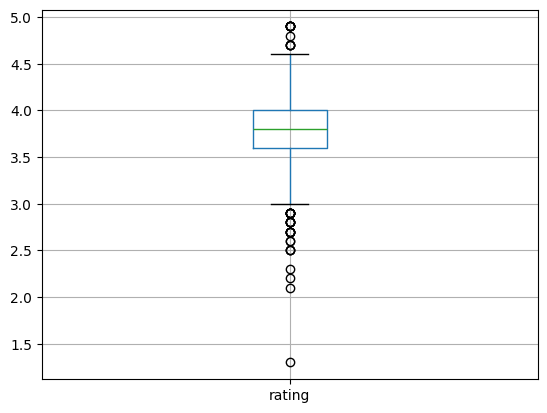

In [166]:
# outliers
import matplotlib.pyplot as plt

df.boxplot(column='rating')
plt.show()

In [ ]:
# top rated comapney
df.sort_values('rating', ascending=False).head(10)

,name,rating,reviews,industry,location
749,Hire In Global,4.9,1400,Recruitment,Mumbai +63 other locations
282,Marpu Foundation,4.9,3100,Non-Profit,Hyderabad +61 other locations
836,Royal Migration Solutions,4.9,1300,Other,Dubai +12 other locations
978,Northcorp Software,4.9,1100,IT Services & Consulting,Gurugram +7 other locations
541,Tekwissen,4.9,1900,IT Services & Consulting,Visakhapatnam +5 other locations
1492,Lavender Technology,4.9,724,IT Services & Consulting,Bengaluru +8 other locations
1147,Regulated Council of Immigration Consultants,4.9,936,Other,Dubai +5 other locations
1468,Evision Technoserve,4.8,739,IT Services & Consulting,Pune +44 other locations
1050,Incheon Motors,4.7,1000,Automobile,Kochi +16 other locations
95,Indian Army,4.7,6300,Defence & Aerospace,New Delhi +363 other locations


In [168]:
# low rated comapney
df.sort_values('rating').head(10)

,name,rating,reviews,industry,location
571,Stellar Migration,1.3,1800,Other,Dubai +7 other locations
1427,Brane Enterprises,2.1,757,Software Product,Hyderabad +12 other locations
1517,uFaber,2.2,712,Education & Training,Mumbai +24 other locations
1370,People Tech Group,2.3,785,IT Services & Consulting,Hyderabad +13 other locations
862,Mu Sigma,2.5,1200,Analytics & KPO,Bengaluru +16 other locations
1577,SG Analytics,2.5,691,Analytics & KPO,Pune +12 other locations
597,HighRadius,2.5,1700,Software Product,Hyderabad +15 other locations
843,Apex Group,2.6,1300,Financial Services,Pune +28 other locations
1423,UnitedLex,2.6,758,Analytics & KPO,New Delhi +13 other locations
353,IntouchCX,2.7,2600,BPO,Hyderabad +22 other locations


In [ ]:
# avg rating by location
df.groupby('location')['rating'].mean().sort_values(ascending=False)

location
Hyderabad +61 other locations       4.9
Dubai +12 other locations           4.9
Bengaluru +8 other locations        4.9
Visakhapatnam +5 other locations    4.9
Dubai +5 other locations            4.9
                                   ... 
Pune +43 other locations            2.8
Mysuru +18 other locations          2.7
Kolkata +17 other locations         2.7
New Delhi +13 other locations       2.6
Dubai +7 other locations            1.3
Name: rating, Length: 1121, dtype: float64

In [170]:
# avg rating by industry
df.groupby('industry')['rating'].mean().sort_values(ascending=False)

industry
Bengaluru +32 other locations     4.500000
Non-Profit                        4.300000
Jewellery                         4.200000
Railways                          4.200000
Petrochemicals                    4.200000
                                    ...   
Mumbai +494 other locations       3.400000
Analytics & KPO                   3.391304
Accounting & Auditing             3.350000
Architecture & Interior Design    3.300000
Content Development               3.100000
Name: rating, Length: 78, dtype: float64

In [171]:
df = df[(df['rating'] >= 1) & (df['rating'] <= 5)]

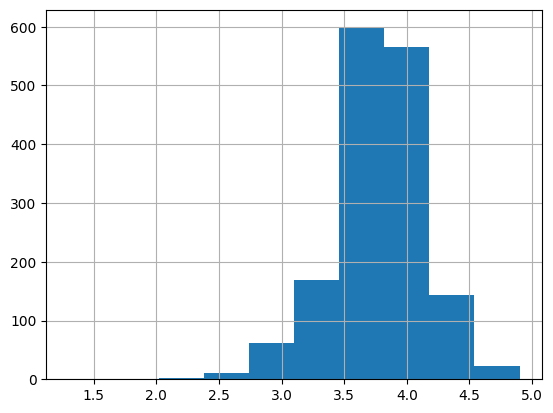

In [172]:
import matplotlib.pyplot as plt

df['rating'].hist(bins=10)
plt.show()

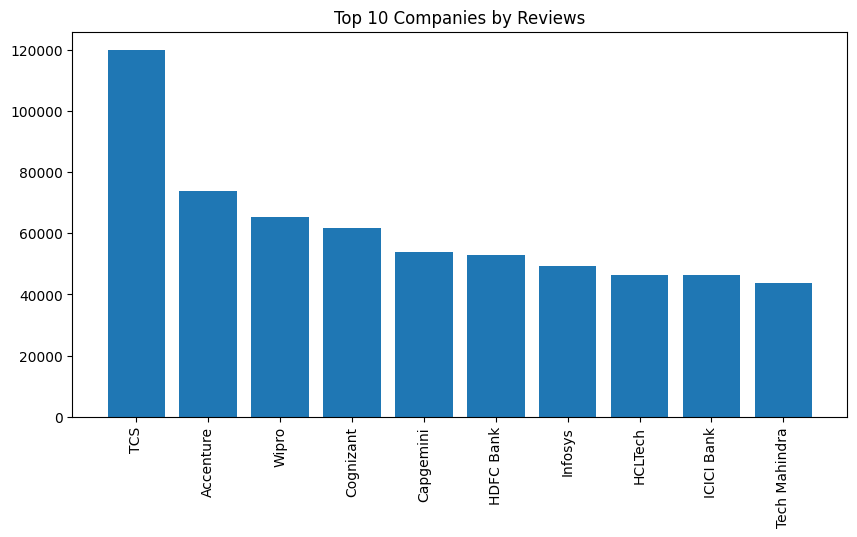

In [183]:
top10 = df.sort_values('reviews', ascending=False).head(10)

plt.figure(figsize=(10,5))
plt.bar(top10['company_name'], top10['reviews'])
plt.xticks(rotation=90)
plt.title("Top 10 Companies by Reviews")
plt.show()

In [182]:
df

,company_name,rating,reviews,industry,location
0,TCS,3.3,120000,IT Services & Consulting,Bengaluru +445 other locations
1,Accenture,3.7,74000,IT Services & Consulting,Bengaluru +259 other locations
2,Wipro,3.6,65500,IT Services & Consulting,Hyderabad +374 other locations
3,Cognizant,3.7,61900,IT Services & Consulting,Hyderabad +233 other locations
4,Capgemini,3.6,53800,IT Services & Consulting,Bengaluru +183 other locations
...,...,...,...,...,...
1575,ChannelPlay,3.8,691,Marketing & Advertising,Gurugram +95 other locations
1576,Bisk Farm,4.0,691,Food Processing,Kolkata +140 other locations
1577,SG Analytics,2.5,691,Analytics & KPO,Pune +12 other locations
1578,Autoliv,3.9,690,Auto Components,Bengaluru +23 other locations


In [ ]:
# rename columns
df=df.rename(columns={
    'name':"company_name"
})

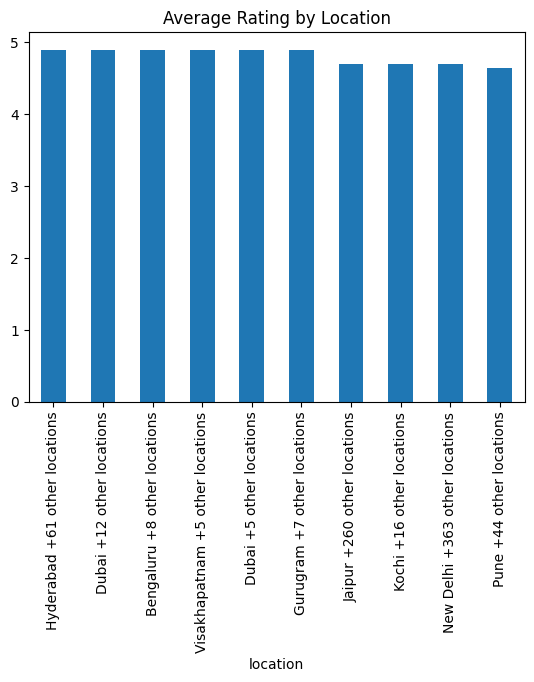

In [184]:
location_rating = df.groupby('location')['rating'].mean().sort_values(ascending=False).head(10)

location_rating.plot(kind='bar')
plt.title("Average Rating by Location")
plt.show()

<Figure size 800x500 with 0 Axes>

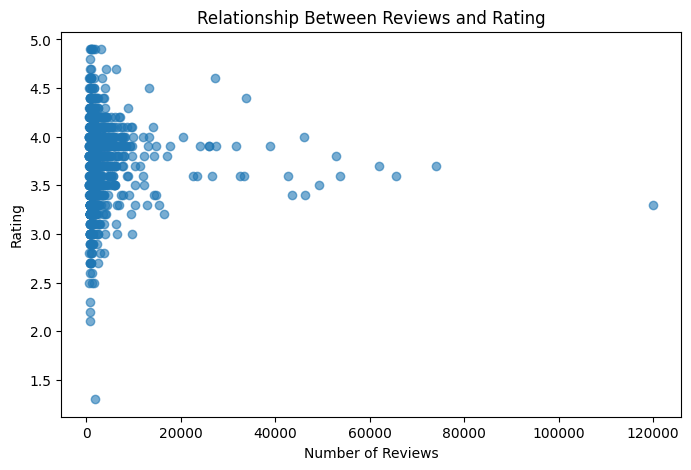

In [189]:
plt.figure(figsize=(8,5))

plt.scatter(df['reviews'], df['rating'], alpha=0.6)

plt.xlabel("Number of Reviews")
plt.ylabel("Rating")
plt.title("Relationship Between Reviews and Rating")

plt.show()

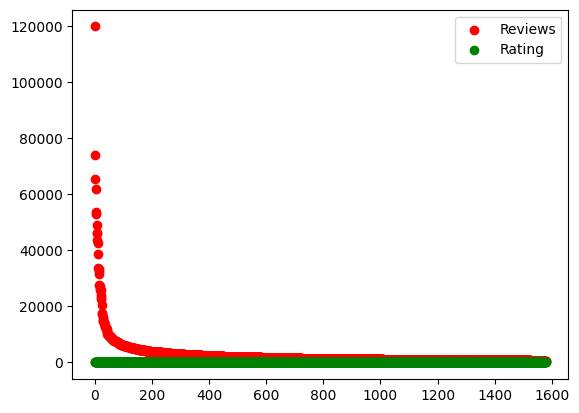

In [190]:
plt.scatter(df.index, df['reviews'], color='red', label='Reviews')
plt.scatter(df.index, df['rating'], color='green', label='Rating')

plt.legend()
plt.show()

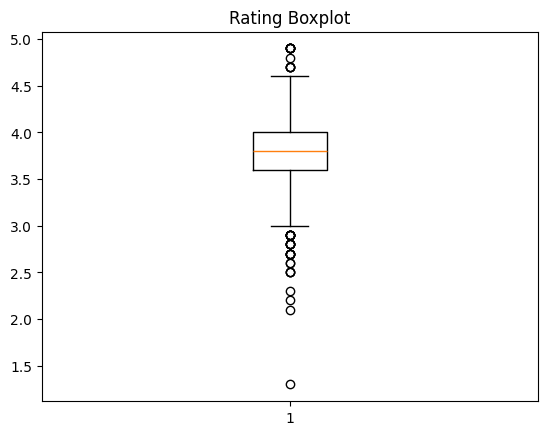

In [194]:
plt.boxplot(df['rating'])
plt.title("Rating Boxplot")
plt.show()

In [201]:
df.groupby('company_name')['rating'].max().sort_values(ascending=False).head(5)

company_name
Royal Migration Solutions                       4.9
Hire In Global                                  4.9
Northcorp Software                              4.9
Lavender Technology                             4.9
Regulated Council of Immigration Consultants    4.9
Name: rating, dtype: float64

In [202]:
def rating_category(rating):
    if rating >= 4.0:
        return "Excellent"
    elif rating >= 3.0:
        return "Good"
    else:
        return "Bad"

df['rating_category'] = df['rating'].apply(rating_category)


In [203]:
df

,company_name,rating,reviews,industry,location,rating_category
0,TCS,3.3,120000,IT Services & Consulting,Bengaluru +445 other locations,Good
1,Accenture,3.7,74000,IT Services & Consulting,Bengaluru +259 other locations,Good
2,Wipro,3.6,65500,IT Services & Consulting,Hyderabad +374 other locations,Good
3,Cognizant,3.7,61900,IT Services & Consulting,Hyderabad +233 other locations,Good
4,Capgemini,3.6,53800,IT Services & Consulting,Bengaluru +183 other locations,Good
...,...,...,...,...,...,...
1575,ChannelPlay,3.8,691,Marketing & Advertising,Gurugram +95 other locations,Good
1576,Bisk Farm,4.0,691,Food Processing,Kolkata +140 other locations,Excellent
1577,SG Analytics,2.5,691,Analytics & KPO,Pune +12 other locations,Bad
1578,Autoliv,3.9,690,Auto Components,Bengaluru +23 other locations,Good


# END project